In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/clean_online_retail.csv', parse_dates=['InvoiceDate'])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [39]:
last_date = df['InvoiceDate'].max()
last_date

Timestamp('2011-12-09 12:50:00')

In [40]:
reference_date = last_date + pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

In [41]:
indate=df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
indate

,CustomerID,InvoiceDate
0,12346,2011-01-18 10:01:00
1,12347,2011-12-07 15:52:00
2,12348,2011-09-25 13:13:00
3,12349,2011-11-21 09:51:00
4,12350,2011-02-02 16:01:00
...,...,...
4331,18280,2011-03-07 09:52:00
4332,18281,2011-06-12 10:53:00
4333,18282,2011-12-02 11:43:00
4334,18283,2011-12-06 12:02:00


In [42]:
indate['recency']=reference_date-indate['InvoiceDate']
indate

,CustomerID,InvoiceDate,recency
0,12346,2011-01-18 10:01:00,326 days 02:49:00
1,12347,2011-12-07 15:52:00,2 days 20:58:00
2,12348,2011-09-25 13:13:00,75 days 23:37:00
3,12349,2011-11-21 09:51:00,19 days 02:59:00
4,12350,2011-02-02 16:01:00,310 days 20:49:00
...,...,...,...
4331,18280,2011-03-07 09:52:00,278 days 02:58:00
4332,18281,2011-06-12 10:53:00,181 days 01:57:00
4333,18282,2011-12-02 11:43:00,8 days 01:07:00
4334,18283,2011-12-06 12:02:00,4 days 00:48:00


In [43]:
indate['recency']=indate['recency'].dt.days
indate

,CustomerID,InvoiceDate,recency
0,12346,2011-01-18 10:01:00,326
1,12347,2011-12-07 15:52:00,2
2,12348,2011-09-25 13:13:00,75
3,12349,2011-11-21 09:51:00,19
4,12350,2011-02-02 16:01:00,310
...,...,...,...
4331,18280,2011-03-07 09:52:00,278
4332,18281,2011-06-12 10:53:00,181
4333,18282,2011-12-02 11:43:00,8
4334,18283,2011-12-06 12:02:00,4


In [44]:
indate=indate.drop(columns=['InvoiceDate'])
indate

,CustomerID,recency
0,12346,326
1,12347,2
2,12348,75
3,12349,19
4,12350,310
...,...,...
4331,18280,278
4332,18281,181
4333,18282,8
4334,18283,4


In [45]:
infreq=df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
infreq.columns=['CustomerID','frequency']
infreq

,CustomerID,frequency
0,12346,1
1,12347,7
2,12348,4
3,12349,1
4,12350,1
...,...,...
4331,18280,1
4332,18281,1
4333,18282,2
4334,18283,16


In [46]:
inmonetary=df.groupby('CustomerID')['TotalPrice'].sum().reset_index()
inmonetary.columns=['CustomerID','monetary']
inmonetary

,CustomerID,monetary
0,12346,77183.60
1,12347,4310.00
2,12348,1437.24
3,12349,1457.55
4,12350,294.40
...,...,...
4331,18280,180.60
4332,18281,80.82
4333,18282,178.05
4334,18283,2039.58


In [47]:
df[df['CustomerID']==12346]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
36392,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom,77183.6


In [48]:
inmonetary=inmonetary[inmonetary['CustomerID'] != 12346]
inmonetary

,CustomerID,monetary
1,12347,4310.00
2,12348,1437.24
3,12349,1457.55
4,12350,294.40
5,12352,1385.74
...,...,...
4331,18280,180.60
4332,18281,80.82
4333,18282,178.05
4334,18283,2039.58


In [49]:
rfm = indate.merge(infreq, on='CustomerID')
rfm = rfm.merge(inmonetary, on='CustomerID')
rfm

,CustomerID,recency,frequency,monetary
0,12347,2,7,4310.00
1,12348,75,4,1437.24
2,12349,19,1,1457.55
3,12350,310,1,294.40
4,12352,36,7,1385.74
...,...,...,...,...
4330,18280,278,1,180.60
4331,18281,181,1,80.82
4332,18282,8,2,178.05
4333,18283,4,16,2039.58


In [50]:
rfm.describe()

,CustomerID,recency,frequency,monetary
count,4335.000000,4335.000000,4335.000000,4335.000000
mean,15299.582468,92.636678,4.248674,1999.283747
std,1721.509107,100.151050,7.648091,8846.046033
min,12347.000000,1.000000,1.000000,0.000000
25%,13812.500000,18.000000,1.000000,304.245000
50%,15298.000000,51.000000,2.000000,661.520000
75%,16778.500000,143.000000,5.000000,1629.870000
max,18287.000000,374.000000,206.000000,279138.020000


In [51]:
rfm.sort_values('monetary', ascending=False).head(10)

,CustomerID,recency,frequency,monetary
1689,14646,2,73,279138.02
4198,18102,1,60,259657.30
3726,17450,8,46,194390.79
3007,16446,1,2,168472.50
1879,14911,1,199,140336.83
54,12415,24,20,124564.53
1333,14156,10,55,117210.08
3769,17511,3,31,91062.38
2701,16029,39,62,72708.09
3175,16684,4,28,66653.56


In [52]:
rfm[rfm['monetary'] == 0]

,CustomerID,recency,frequency,monetary
684,13256,14,1,0.0


In [53]:
df[df['CustomerID'] == 13256]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
364504,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.0,13256,United Kingdom,0.0


In [54]:
rfm['monetary_log'] = np.log1p(rfm['monetary'])
rfm['frequency_log'] = np.log1p(rfm['frequency'])

In [55]:
rfm

,CustomerID,recency,frequency,monetary,monetary_log,frequency_log
0,12347,2,7,4310.00,8.368925,2.079442
1,12348,75,4,1437.24,7.271175,1.609438
2,12349,19,1,1457.55,7.285198,0.693147
3,12350,310,1,294.40,5.688330,0.693147
4,12352,36,7,1385.74,7.234711,2.079442
...,...,...,...,...,...,...
4330,18280,278,1,180.60,5.201806,0.693147
4331,18281,181,1,80.82,4.404522,0.693147
4332,18282,8,2,178.05,5.187665,1.098612
4333,18283,4,16,2039.58,7.620989,2.833213


In [56]:
rfm.describe()

,CustomerID,recency,frequency,monetary,monetary_log,frequency_log
count,4335.000000,4335.000000,4335.000000,4335.000000,4335.000000,4335.000000
mean,15299.582468,92.636678,4.248674,1999.283747,6.572884,1.341920
std,1721.509107,100.151050,7.648091,8846.046033,1.257523,0.681966
min,12347.000000,1.000000,1.000000,0.000000,0.000000,0.693147
25%,13812.500000,18.000000,1.000000,304.245000,5.721115,0.693147
50%,15298.000000,51.000000,2.000000,661.520000,6.496051,1.098612
75%,16778.500000,143.000000,5.000000,1629.870000,7.396869,1.791759
max,18287.000000,374.000000,206.000000,279138.020000,12.539465,5.332719


In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [58]:
features = rfm[['recency', 'frequency_log', 'monetary_log']]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['recency_scaled', 'frequency_scaled', 'monetary_scaled'])
rfm_scaled_df.describe()

,recency_scaled,frequency_scaled,monetary_scaled
count,4.335000e+03,4.335000e+03,4.335000e+03
mean,-3.278167e-17,3.933801e-17,1.049013e-16
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.150903e-01,-9.514365e-01,-5.227452e+00
25%,-7.453271e-01,-9.514365e-01,-6.774169e-01
50%,-4.157868e-01,-3.568146e-01,-6.110598e-02
75%,5.029316e-01,6.596983e-01,6.553195e-01
max,2.809714e+00,5.852579e+00,4.745255e+00


In [59]:
inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

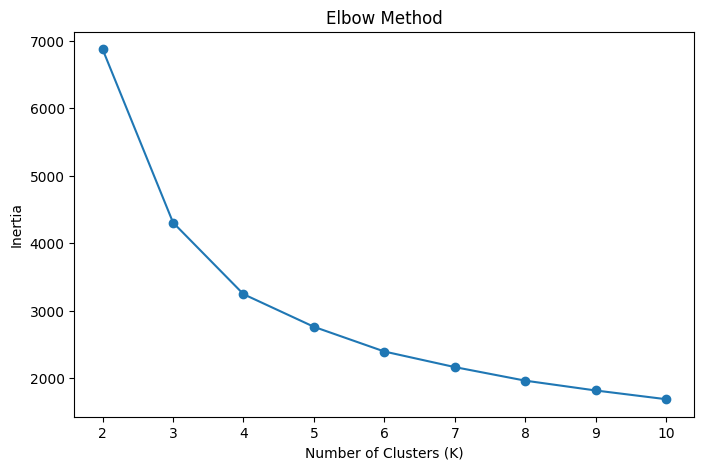

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

K=2: Silhouette Score = 0.4061
K=3: Silhouette Score = 0.4152
K=4: Silhouette Score = 0.3800
K=5: Silhouette Score = 0.3457
K=6: Silhouette Score = 0.3322
K=7: Silhouette Score = 0.3030
K=8: Silhouette Score = 0.3001
K=9: Silhouette Score = 0.2829
K=10: Silhouette Score = 0.2829


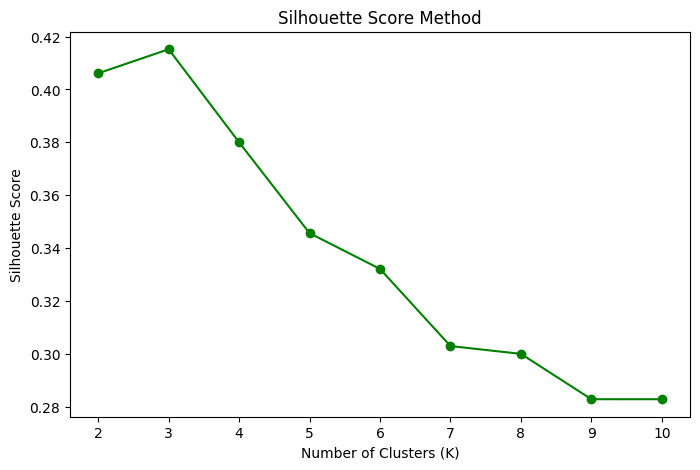

In [69]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, cluster_labels)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.4f}")

# رسم النتيجة
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o', color='green')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Method")
plt.show()

 اخترنا K=3 بناءً على الـ Silhouette Score (0.415)، وهو أعلى من K=4 (0.38)
 رغم إن الـ Elbow Method كان بيرجح K=4 بشكل أضعف
 اعتمدنا الـ Silhouette كمعيار حاسم لأنه بيقيس جودة الفصل الفعلي بين المجموعات

In [70]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [71]:
cluster_profile = rfm.groupby("Cluster")[[
    "recency",
    "frequency",
    "monetary"
]].mean()

cluster_profile

,recency,frequency,monetary
Cluster,,,
0,54.614625,2.029644,603.277452
1,29.813585,9.766038,5317.825917
2,255.108519,1.389452,405.417993


In [72]:
segment_names = {
    0: "normal customers",
    1: "Champions",
    2: "Lost",
}
rfm["Segment"] = rfm["Cluster"].map(segment_names)

In [73]:
rfm

,CustomerID,recency,frequency,monetary,monetary_log,frequency_log,Cluster,Segment
0,12347,2,7,4310.00,8.368925,2.079442,1,Champions
1,12348,75,4,1437.24,7.271175,1.609438,1,Champions
2,12349,19,1,1457.55,7.285198,0.693147,0,normal customers
3,12350,310,1,294.40,5.688330,0.693147,2,Lost
4,12352,36,7,1385.74,7.234711,2.079442,1,Champions
...,...,...,...,...,...,...,...,...
4330,18280,278,1,180.60,5.201806,0.693147,2,Lost
4331,18281,181,1,80.82,4.404522,0.693147,2,Lost
4332,18282,8,2,178.05,5.187665,1.098612,0,normal customers
4333,18283,4,16,2039.58,7.620989,2.833213,1,Champions


In [74]:
rfm["Segment"].value_counts()

Segment
normal customers    2024
Champions           1325
Lost                 986
Name: count, dtype: int64

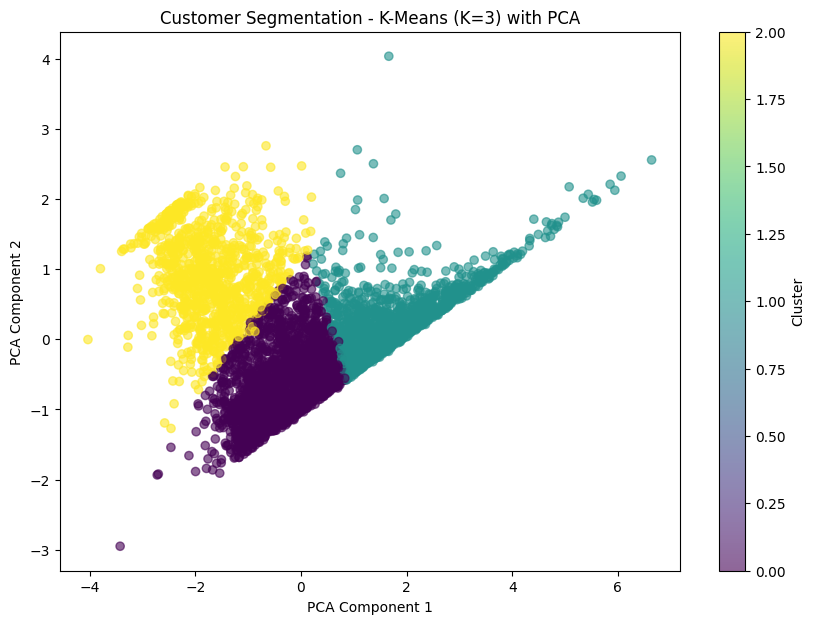

In [76]:

pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(10, 7))

plt.scatter(
    rfm_pca[:, 0],
    rfm_pca[:, 1],
    c=rfm["Cluster"],
    alpha=0.6
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segmentation - K-Means (K=3) with PCA")
plt.colorbar(label="Cluster")

plt.show()

In [77]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.72085468 0.21568243]
0.9365371132038481


In [78]:
rfm.to_csv("../data/customer_segments.csv", index=False)

In [79]:
import joblib

joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(kmeans, '../models/kmeans_model.pkl')

['../models/kmeans_model.pkl']